# PAGA Trajectory Inference on LARRY Day-2 Data (cluster-level Markov absorption)

PAGA (Wolf et al. 2019) abstracts the single-cell graph into a **cluster-level** graph.
Here we build a *custom cluster-level absorbing Markov chain*: cluster connectivities from
PAGA are directed by mean DPT pseudotime, terminal (absorbing) clusters are identified by
mapping Leiden clusters to cell-type annotations, fate probabilities are computed per
non-terminal cluster via absorption, and broadcast back to cells by cluster membership.

This notebook **mirrors `02_palantir.ipynb`** (same day-2 subset, same HSC root cell, same
evaluation in section 8) so PAGA and Palantir results are directly comparable. PAGA is the
*cluster-level* granularity counterpart to Palantir (cell-level) and CellRank2 (macrostate).

## 1. Imports

In [1]:
%matplotlib inline
import sys
print(f"Python: {sys.executable}")

import warnings
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import anndata

warnings.filterwarnings("ignore")
sc.settings.verbosity = 1
anndata.settings.allow_write_nullable_strings = True

PREPROCESSED_H5AD = "larry_preprocessed.h5ad"
OUTPUT_H5AD = "larry_day2_paga.h5ad"
PALANTIR_H5AD = "larry_day2_palantir.h5ad"   # used only for the side-by-side comparison

time_col = "Time point"
celltype_col = "Cell type annotation"
clone_col = "clone_idx"

pseudo_key = "dpt_pseudotime"
fate_prob_key = "paga_fate_probabilities"
fate_names_key = "paga_fate_names"

print(f"scanpy {sc.__version__}")

Python: /opt/miniconda3/envs/cs179/bin/python


scanpy 1.11.5


## 2. Load preprocessed data

In [2]:
adata_full = anndata.read_h5ad(PREPROCESSED_H5AD)
print(adata_full)
print("\nobs columns:", list(adata_full.obs.columns))
print("obsm keys:  ", list(adata_full.obsm.keys()))

AnnData object with n_obs × n_vars = 130887 × 2000
    obs: 'Library', 'Cell barcode', 'Time point', 'Starting population', 'Cell type annotation', 'Well', 'SPRING-x', 'SPRING-y', 'clone_idx', 'total_counts', 'n_genes_detected', 'fate_train', 'fate_test', 'fate_frac_Baso', 'fate_frac_Ccr7_DC', 'fate_frac_Eos', 'fate_frac_Erythroid', 'fate_frac_Lymphoid', 'fate_frac_Mast', 'fate_frac_Meg', 'fate_frac_Monocyte', 'fate_frac_Neutrophil', 'fate_frac_Undifferentiated', 'fate_frac_pDC'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_clone', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts_norm', 'log1p_norm'
    obsp: 'connectivities', 'distances'

obs columns: ['Library', 'Cell barcode', 'Time point', 'Starting population', 'Cell type annotation', 'Well', 'SPRING-x', 'SPRING-y', 'clone_idx', 'total_counts', 'n_genes_detected', 'fate_train', 'fate_test', 'fate_frac_Baso', 'fate_frac_Ccr

## 3. Subset to day-2 cells

In [3]:
adata_d2 = adata_full[adata_full.obs[time_col] == 2].copy()
print(f"Day-2 cells: {adata_d2.n_obs:,} / {adata_full.n_obs:,}")

if clone_col in adata_d2.obs.columns:
    n_cloned = (adata_d2.obs[clone_col].fillna(-1).astype(int) >= 0).sum()
    print(f"  With clonal lineage info: {n_cloned:,} ({100*n_cloned/adata_d2.n_obs:.1f}%)")

if celltype_col in adata_d2.obs.columns:
    n_ct = adata_d2.obs[celltype_col].notna().sum()
    print(f"  With cell-type annotation: {n_ct:,}")
    print(adata_d2.obs[celltype_col].value_counts())

Day-2 cells: 28,249 / 130,887
  With clonal lineage info: 4,638 (16.4%)
  With cell-type annotation: 28,249
Cell type annotation
Undifferentiated    25575
Neutrophil           1068
Monocyte              950
Baso                  187
Lymphoid              144
Erythroid             100
Meg                    97
Ccr7_DC                57
Mast                   40
pDC                    16
Eos                    15
Name: count, dtype: int64


## 4. k-NN graph and UMAP (day-2 subset)

Recompute the neighbor graph on the day-2 cells only, exactly as the Palantir notebook does,
so the two methods operate on the same cell graph.

In [4]:
print("Computing k-NN graph (n_neighbors=30, n_pcs=50)...")
sc.pp.neighbors(adata_d2, n_neighbors=30, n_pcs=50, use_rep="X_pca")

print("Computing UMAP for visualization...")
sc.tl.umap(adata_d2, random_state=42)

umap_d2 = adata_d2.obsm["X_umap"]
print("Done. obsm keys:", list(adata_d2.obsm.keys()))

Computing k-NN graph (n_neighbors=30, n_pcs=50)...


Computing UMAP for visualization...


Done. obsm keys: ['X_clone', 'X_pca', 'X_umap']


## 5. Select start (root) cell

Same HSC/LMPP marker scoring as Palantir section 5 — pick the day-2 cell with the highest
composite stem-marker score as the DPT root.

In [5]:
def get_gene_expr(adata, gene_name, prefer_layer="log1p_norm"):
    """Dense expression array for gene_name; prefers log1p_norm layer over scaled X."""
    hits = adata.var.index[adata.var.index == gene_name].tolist()
    if not hits:
        return None
    idx = adata.var.index.tolist().index(hits[0])
    if prefer_layer in adata.layers:
        col = adata.layers[prefer_layer][:, idx]
    else:
        col = adata.X[:, idx]
    return np.asarray(col.todense()).flatten() if sp.issparse(col) else np.asarray(col).flatten()


hsc_markers = ["Procr", "Ly6a", "Flt3", "Gata2", "Kit", "Cd34"]
score = np.zeros(adata_d2.n_obs)
found_markers = []

for gene in hsc_markers:
    expr = get_gene_expr(adata_d2, gene)
    if expr is not None:
        mx = expr.max()
        if mx > 0:
            score += expr / mx
        found_markers.append(gene)

if found_markers:
    start_idx = int(np.argmax(score))
else:
    pca_d2 = adata_d2.obsm["X_pca"][:, :10]
    centroid = pca_d2.mean(axis=0)
    start_idx = int(np.argmin(np.linalg.norm(pca_d2 - centroid, axis=1)))

start_cell = adata_d2.obs_names[start_idx]
print(f"HSC markers found: {found_markers}")
print(f"Start cell (max HSC score): {start_cell}  (index {start_idx})")
ct = adata_d2.obs.loc[start_cell, celltype_col] if celltype_col in adata_d2.obs else "?"
print(f"Cell type: {ct}")

HSC markers found: ['Procr', 'Ly6a', 'Flt3', 'Gata2', 'Kit', 'Cd34']
Start cell (max HSC score): 52785  (index 18261)
Cell type: Undifferentiated


## 6. DPT pseudotime, Leiden clustering, PAGA graph

In [6]:
adata_d2.uns["iroot"] = start_idx

print("Computing diffusion map + DPT pseudotime...")
sc.tl.diffmap(adata_d2)
sc.tl.dpt(adata_d2)
pt = adata_d2.obs[pseudo_key]
print(f"DPT pseudotime range: {pt.min():.3f} - {pt.max():.3f}")

print("\nLeiden clustering (resolution=2.0)...")
sc.tl.leiden(adata_d2, resolution=2.0, key_added="leiden",
             flavor="igraph", n_iterations=2, directed=False, random_state=0)
n_clusters = adata_d2.obs["leiden"].nunique()
print(f"Leiden clusters: {n_clusters}")

print("Running PAGA...")
sc.tl.paga(adata_d2, groups="leiden")
print("PAGA connectivities shape:", adata_d2.uns["paga"]["connectivities"].shape)

Computing diffusion map + DPT pseudotime...


DPT pseudotime range: 0.000 - 1.000

Leiden clustering (resolution=2.0)...


Leiden clusters: 24
Running PAGA...


PAGA connectivities shape: (24, 24)


## 7. Identify absorbing (terminal) clusters

Map each Leiden cluster to its dominant committed cell type. A cluster is an **absorbing
state for fate F** if its dominant committed type is F and committed cells make up at least
`TERM_FRAC_THRESHOLD` of the cluster. To guarantee the same lineage coverage Palantir reports
on day-2, any committed lineage present but unmatched gets a fallback terminal: the most
enriched not-yet-terminal cluster for that lineage. All other clusters are transient.

In [7]:
COMMITTED = ["Neutrophil", "Monocyte", "Baso", "Mast", "Meg",
             "Erythroid", "Lymphoid", "Eos", "Ccr7_DC", "pDC"]
TERM_FRAC_THRESHOLD = 0.5

leiden = adata_d2.obs["leiden"].astype(str)
clusters = sorted(leiden.unique(), key=lambda x: int(x))
n_clust = len(clusters)
cl_index = {c: i for i, c in enumerate(clusters)}

# mean DPT per cluster
mean_dpt = np.array([adata_d2.obs.loc[(leiden == c).values, pseudo_key].mean() for c in clusters])

# per-cluster dominant committed type, committed fraction, per-lineage fraction
ct_series = adata_d2.obs[celltype_col]
cluster_dom, cluster_committed_frac = {}, {}
lineage_frac = pd.DataFrame(0.0, index=clusters, columns=COMMITTED)
for c in clusters:
    mask = (leiden == c).values
    total = mask.sum()
    cells_ct = ct_series[mask]
    committed_counts = cells_ct[cells_ct.isin(COMMITTED)].value_counts()
    for L in COMMITTED:
        lineage_frac.loc[c, L] = committed_counts.get(L, 0) / total
    if committed_counts.sum() > 0:
        cluster_dom[c] = committed_counts.idxmax()
        cluster_committed_frac[c] = committed_counts.sum() / total
    else:
        cluster_dom[c] = None
        cluster_committed_frac[c] = 0.0

# primary terminal assignment: dominant committed type passing the purity threshold
terminal_fate = {}
for c in clusters:
    dom = cluster_dom[c]
    if dom is not None and cluster_committed_frac[c] >= TERM_FRAC_THRESHOLD:
        terminal_fate[c] = dom

# fallback: ensure every committed lineage present in day-2 has >=1 terminal cluster
present_lineages = [L for L in COMMITTED if (ct_series == L).sum() > 0]
for L in present_lineages:
    if L not in terminal_fate.values():
        for cand in lineage_frac[L].sort_values(ascending=False).index:
            if lineage_frac.loc[cand, L] <= 0:
                break
            if cand not in terminal_fate:
                terminal_fate[cand] = L
                break

terminal_clusters = sorted(terminal_fate.keys(), key=lambda x: int(x))
transient_clusters = [c for c in clusters if c not in terminal_fate]

print(f"Terminal clusters: {len(terminal_clusters)}  ->  fates {sorted(set(terminal_fate.values()))}")
for c in terminal_clusters:
    print(f"  cluster {c:>3s}: {terminal_fate[c]:12s} "
          f"(committed frac {cluster_committed_frac[c]:.2f}, mean DPT {mean_dpt[cl_index[c]]:.3f})")
print(f"Transient clusters: {len(transient_clusters)}")

Terminal clusters: 8  ->  fates ['Baso', 'Ccr7_DC', 'Eos', 'Erythroid', 'Lymphoid', 'Meg', 'Monocyte', 'Neutrophil']
  cluster   5: Neutrophil   (committed frac 0.98, mean DPT 0.376)
  cluster   6: Baso         (committed frac 0.24, mean DPT 0.233)
  cluster   7: Meg          (committed frac 0.12, mean DPT 0.201)
  cluster   8: Erythroid    (committed frac 0.00, mean DPT 0.081)
  cluster  18: Monocyte     (committed frac 0.74, mean DPT 0.239)
  cluster  19: Lymphoid     (committed frac 0.07, mean DPT 0.021)
  cluster  21: Eos          (committed frac 0.27, mean DPT 0.608)
  cluster  23: Ccr7_DC      (committed frac 0.58, mean DPT 0.350)
Transient clusters: 16


## 8. Directed cluster Markov chain and absorption probabilities

Connectivities are directed forward in pseudotime (edges only go from a lower-mean-DPT
cluster to a higher one — this keeps the directed graph acyclic). Terminal clusters are made
absorbing. Fate probabilities for transient clusters come from the absorbing-chain
fundamental matrix `B = (I - Q)^{-1} R`, then terminal clusters sharing a fate are summed and
the per-cluster fate matrix is broadcast to cells via cluster membership.

In [8]:
conn = adata_d2.uns["paga"]["connectivities"]
conn = conn.toarray() if sp.issparse(conn) else np.asarray(conn)

# Build row-stochastic directed transition matrix over clusters
T = np.zeros((n_clust, n_clust))
for i in range(n_clust):
    ci = clusters[i]
    if ci in terminal_fate:
        T[i, i] = 1.0                      # absorbing
        continue
    for j in range(n_clust):
        if i != j and conn[i, j] > 0 and mean_dpt[j] > mean_dpt[i]:
            T[i, j] = conn[i, j]           # forward edge only
    rsum = T[i].sum()
    if rsum > 0:
        T[i] /= rsum
    else:
        # transient dead-end: route to best-connected terminal (preserves acyclicity)
        term_conns = [(conn[i, cl_index[c]], cl_index[c])
                      for c in terminal_clusters if conn[i, cl_index[c]] > 0]
        if term_conns:
            T[i, max(term_conns)[1]] = 1.0
        # else: isolated transient -> leave row zero (no fate mass)

# Absorption: B = (I - Q)^-1 R
trans_idx = [cl_index[c] for c in transient_clusters]
absb_idx = [cl_index[c] for c in terminal_clusters]
absorp = np.zeros((n_clust, len(absb_idx)))
if trans_idx:
    Q = T[np.ix_(trans_idx, trans_idx)]
    R = T[np.ix_(trans_idx, absb_idx)]
    A = np.eye(len(trans_idx)) - Q
    try:
        B = np.linalg.inv(A) @ R
    except np.linalg.LinAlgError:
        B = np.linalg.lstsq(A, R, rcond=None)[0]
    for k, ti in enumerate(trans_idx):
        absorp[ti] = B[k]
for k, ai in enumerate(absb_idx):
    absorp[ai, k] = 1.0

# Collapse terminal clusters that share a fate
fate_names = sorted(set(terminal_fate.values()))
cluster_fate = np.zeros((n_clust, len(fate_names)))
for k, c in enumerate(terminal_clusters):
    cluster_fate[:, fate_names.index(terminal_fate[c])] += absorp[:, k]
row_sums = cluster_fate.sum(axis=1, keepdims=True)
cluster_fate = np.divide(cluster_fate, row_sums, where=row_sums > 0)

# Broadcast cluster fate probabilities to cells
leiden_codes = leiden.map(cl_index).values
fate_mat = cluster_fate[leiden_codes]
adata_d2.obsm[fate_prob_key] = fate_mat
adata_d2.uns[fate_names_key] = list(fate_names)
for k, f in enumerate(fate_names):
    adata_d2.obs[f"paga_fate_{f}"] = fate_mat[:, k]

print("Fate names:", fate_names)
print("Per-cell fate prob matrix:", fate_mat.shape)
print("Row-sum range (cells with fate mass): "
      f"{fate_mat.sum(1).min():.3f} - {fate_mat.sum(1).max():.3f}")

Fate names: ['Baso', 'Ccr7_DC', 'Eos', 'Erythroid', 'Lymphoid', 'Meg', 'Monocyte', 'Neutrophil']
Per-cell fate prob matrix: (28249, 8)
Row-sum range (cells with fate mass): 1.000 - 1.000


## 9. Model-specific visualizations

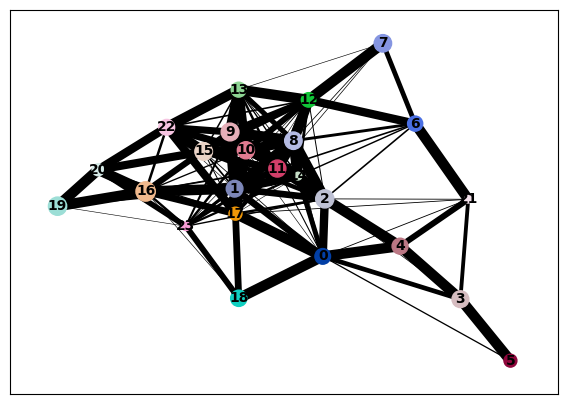

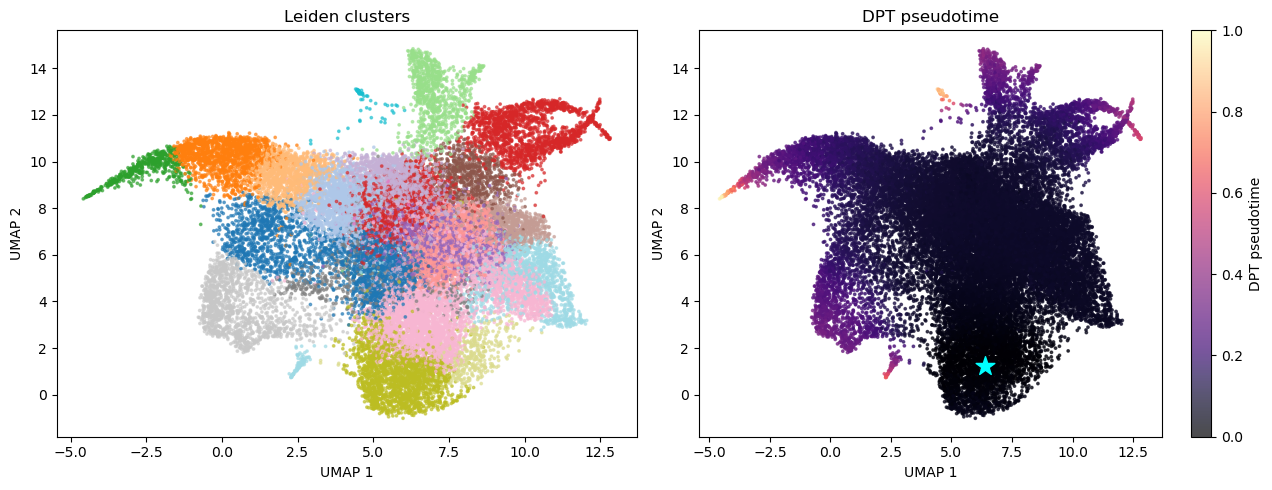

In [9]:
# PAGA abstracted graph
sc.pl.paga(adata_d2, threshold=0.05, color="leiden", show=False)
plt.savefig("paga_graph.png", dpi=80, bbox_inches="tight")
plt.show()

# UMAP: Leiden clusters and DPT pseudotime
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cl_codes = leiden.map(cl_index).values
sc0 = axes[0].scatter(umap_d2[:, 0], umap_d2[:, 1], s=3, alpha=0.6,
                      c=cl_codes, cmap="tab20")
axes[0].set_title("Leiden clusters"); axes[0].set_xlabel("UMAP 1"); axes[0].set_ylabel("UMAP 2")
sc1 = axes[1].scatter(umap_d2[:, 0], umap_d2[:, 1], s=3, alpha=0.7,
                      c=adata_d2.obs[pseudo_key].values, cmap="magma")
plt.colorbar(sc1, ax=axes[1], label="DPT pseudotime")
axes[1].scatter(umap_d2[start_idx, 0], umap_d2[start_idx, 1], s=200, color="cyan", marker="*", zorder=5)
axes[1].set_title("DPT pseudotime"); axes[1].set_xlabel("UMAP 1"); axes[1].set_ylabel("UMAP 2")
plt.tight_layout(); plt.savefig("paga_dpt_umap.png", dpi=80, bbox_inches="tight"); plt.show()

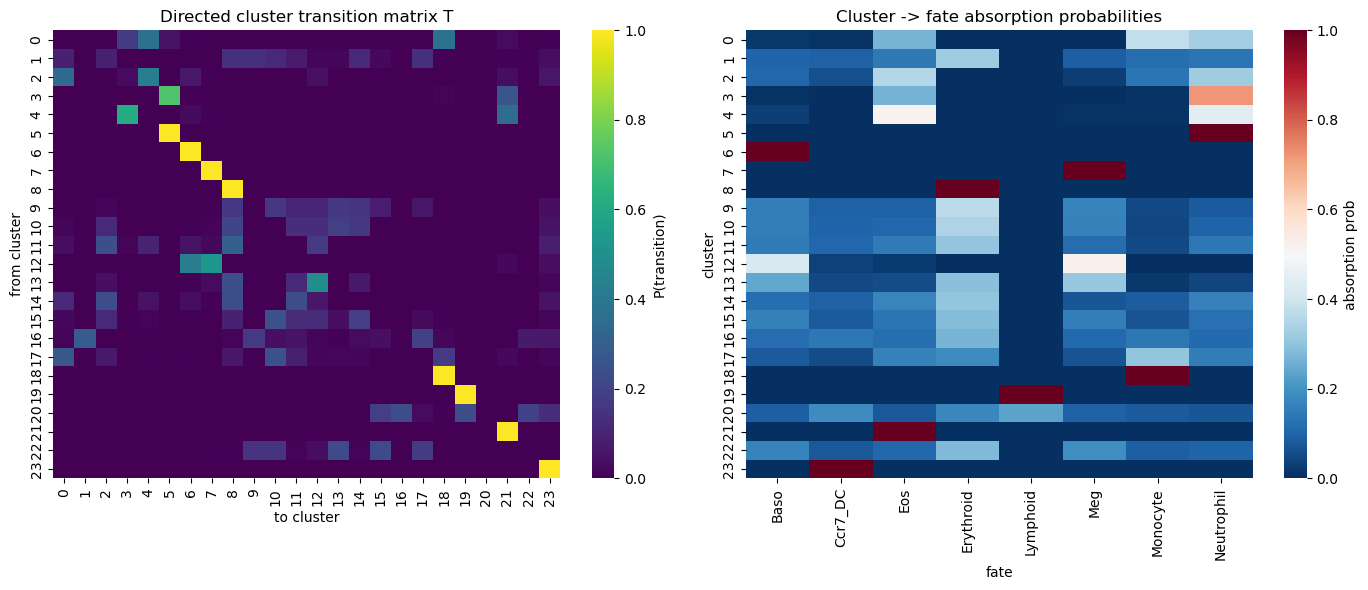

In [10]:
# Directed cluster transition matrix and cluster->fate absorption matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(pd.DataFrame(T, index=clusters, columns=clusters), cmap="viridis",
            ax=axes[0], cbar_kws={"label": "P(transition)"})
axes[0].set_title("Directed cluster transition matrix T"); axes[0].set_xlabel("to cluster"); axes[0].set_ylabel("from cluster")
sns.heatmap(pd.DataFrame(cluster_fate, index=clusters, columns=fate_names), cmap="RdBu_r",
            vmin=0, vmax=1, annot=False, ax=axes[1], cbar_kws={"label": "absorption prob"})
axes[1].set_title("Cluster -> fate absorption probabilities"); axes[1].set_xlabel("fate"); axes[1].set_ylabel("cluster")
plt.tight_layout(); plt.savefig("paga_cluster_transition.png", dpi=80, bbox_inches="tight"); plt.show()

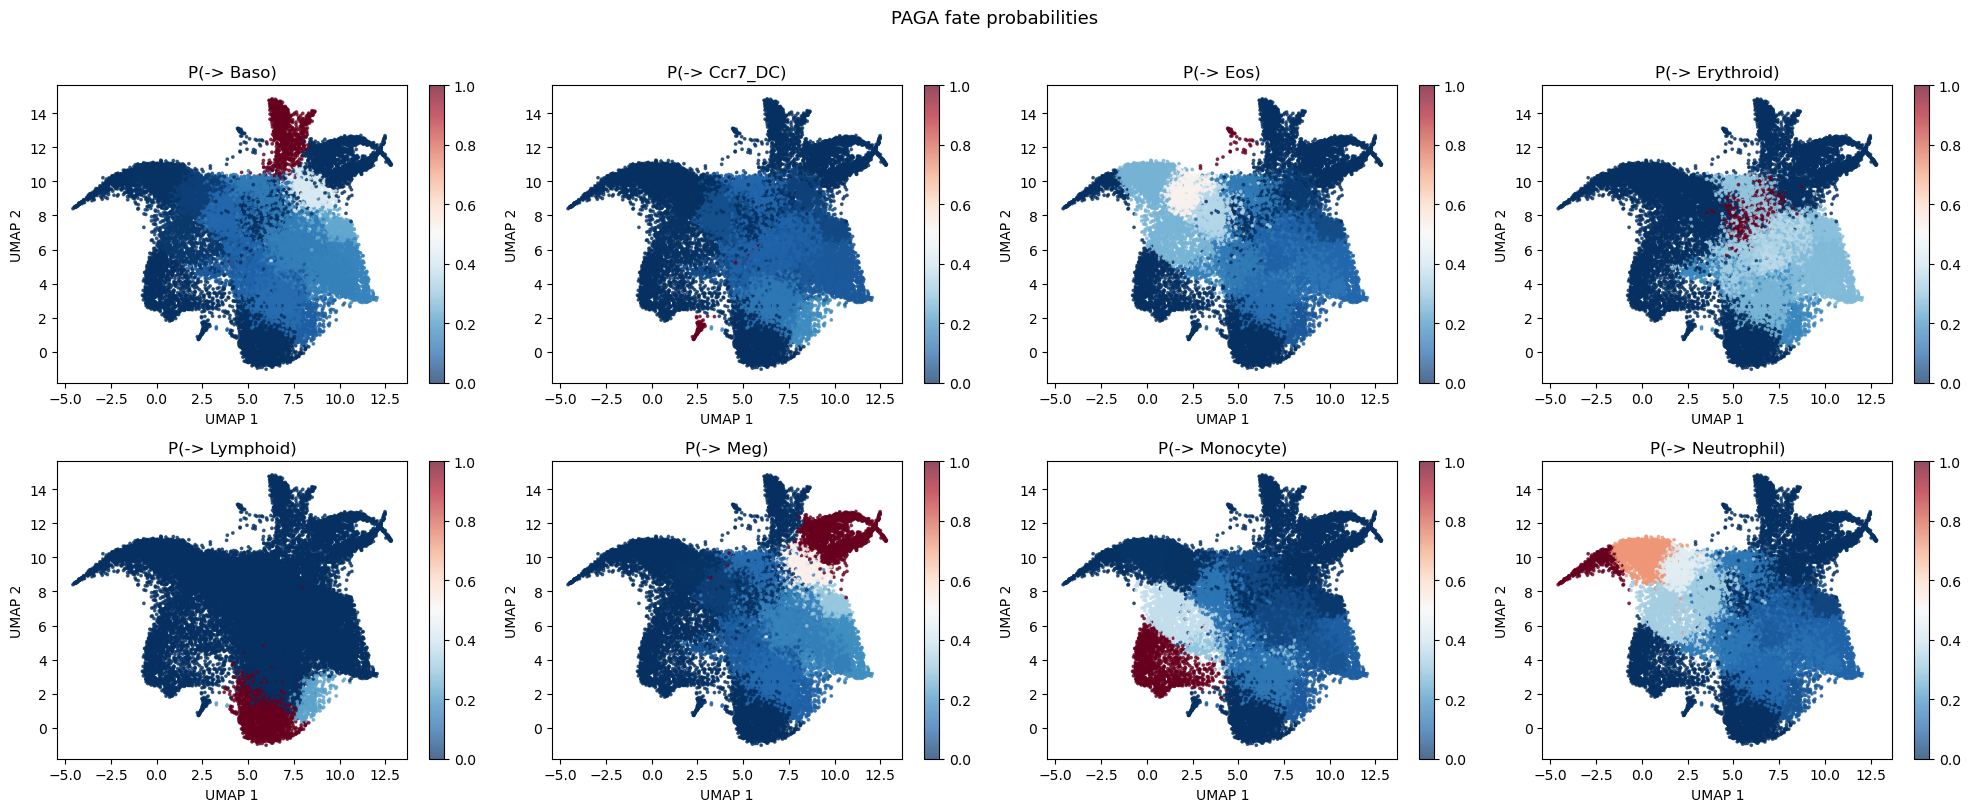

In [11]:
# Per-fate probability on UMAP (mirror Palantir fate-probability panels)
bp_arr = adata_d2.obsm[fate_prob_key]
branch_names = adata_d2.uns[fate_names_key]
n_branches = len(branch_names)
ncols = min(n_branches, 4)
nrows = (n_branches + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.atleast_1d(axes).flatten()
for i, (bname, ax) in enumerate(zip(branch_names, axes)):
    sc_ = ax.scatter(umap_d2[:, 0], umap_d2[:, 1], s=3, alpha=0.7,
                     c=bp_arr[:, i], cmap="RdBu_r", vmin=0, vmax=1)
    plt.colorbar(sc_, ax=ax)
    ax.set_title(f"P(-> {bname})"); ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
for ax in axes[n_branches:]:
    ax.set_visible(False)
plt.suptitle("PAGA fate probabilities", fontsize=13, y=1.01)
plt.tight_layout(); plt.savefig("paga_fate_umap.png", dpi=80, bbox_inches="tight"); plt.show()

## 10. Evaluate against clonal ground-truth fate labels

Identical evaluation to Palantir section 8 (so the numbers are directly comparable): Pearson
r grid, Neu-Mono bias, Wasserstein variants, and cross-entropy, all computed on the day-2
cells that carry clonal `fate_frac_*` labels.

In [12]:
# Fate fractions were computed in notebook 01 and saved as fate_frac_* columns
fate_frac_cols = sorted(c for c in adata_d2.obs.columns if c.startswith("fate_frac_"))
print(f"Fate fraction columns found: {len(fate_frac_cols)}")

has_fate = pd.Series(False, index=adata_d2.obs_names)
if fate_frac_cols:
    has_fate = adata_d2.obs[fate_frac_cols[0]].notna()
    n = has_fate.sum()
    print(f"Day-2 cells with ground-truth fate fractions: {n:,} / {adata_d2.n_obs:,}")
    means = adata_d2.obs.loc[has_fate, fate_frac_cols].mean().sort_values(ascending=False)
    print("\nMean fate fractions across cloned day-2 cells:")
    print(means.rename(lambda c: c.replace("fate_frac_", "")).round(3).to_string())
else:
    print("No fate_frac_* columns found.")

Fate fraction columns found: 11
Day-2 cells with ground-truth fate fractions: 2,621 / 28,249

Mean fate fractions across cloned day-2 cells:
Undifferentiated    0.387
Neutrophil          0.231
Monocyte            0.205
Baso                0.084
Meg                 0.033
Lymphoid            0.025
Mast                0.017
Erythroid           0.006
Eos                 0.006
Ccr7_DC             0.005
pDC                 0.002


In [13]:
fate_df_norm = None
if fate_frac_cols and has_fate.sum() > 0:
    fate_df_norm = adata_d2.obs.loc[has_fate, fate_frac_cols].copy()
    fate_df_norm = fate_df_norm.loc[:, fate_df_norm.sum() > 0]
    fate_df_norm.columns = [c.replace("fate_frac_", "") for c in fate_df_norm.columns]
    print(f"Ground-truth fate matrix: {fate_df_norm.shape[0]:,} cells x {fate_df_norm.shape[1]} lineages")
    print(f"Lineages: {list(fate_df_norm.columns)}")
else:
    print("Skipping: no fate fractions available.")

Ground-truth fate matrix: 2,621 cells x 11 lineages
Lineages: ['Baso', 'Ccr7_DC', 'Eos', 'Erythroid', 'Lymphoid', 'Mast', 'Meg', 'Monocyte', 'Neutrophil', 'Undifferentiated', 'pDC']


### 10a. Pearson r grid (observed fate fraction x PAGA fate probability)

Cells with both PAGA probs and fate labels: 2,621

Pearson r (observed fate fraction x PAGA fate probability):
                   Baso  Ccr7_DC    Eos  Erythroid  Lymphoid    Meg  Monocyte  Neutrophil
Baso              0.532   -0.144 -0.214     -0.099    -0.053  0.032    -0.090      -0.206
Ccr7_DC          -0.038   -0.020 -0.028     -0.032     0.052 -0.032     0.189      -0.024
Eos               0.149   -0.042 -0.027     -0.007    -0.016 -0.040    -0.036      -0.034
Erythroid        -0.055   -0.066 -0.090     -0.059    -0.016  0.264    -0.052      -0.080
Lymphoid         -0.052    0.113 -0.062     -0.008     0.277 -0.061     0.011      -0.066
Mast              0.306   -0.109 -0.134     -0.112    -0.024  0.096    -0.079      -0.115
Meg              -0.080   -0.141 -0.176     -0.134    -0.032  0.513    -0.095      -0.158
Monocyte         -0.162    0.111  0.155      0.005    -0.055 -0.205     0.327       0.111
Neutrophil       -0.210   -0.161  0.477     -0.074    -0.094 -0.256    -0.089  

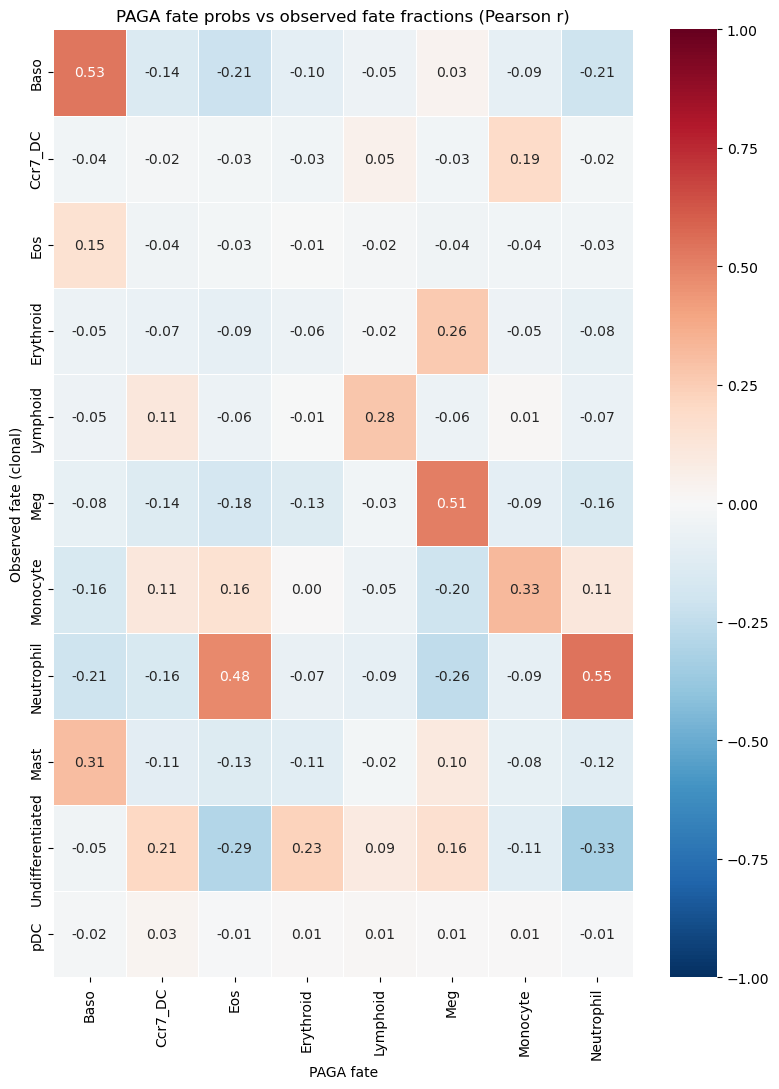

In [14]:
corr_df = None
if fate_df_norm is not None and fate_prob_key in adata_d2.obsm:
    branch_names = adata_d2.uns[fate_names_key]
    bp_df = pd.DataFrame(adata_d2.obsm[fate_prob_key], index=adata_d2.obs_names, columns=branch_names)

    common = fate_df_norm.index.intersection(bp_df.index)
    print(f"Cells with both PAGA probs and fate labels: {len(common):,}")
    fate_sub = fate_df_norm.loc[common]
    bp_sub = bp_df.loc[common]

    corr_mat = np.zeros((len(fate_sub.columns), len(bp_sub.columns)))
    for i, fc in enumerate(fate_sub.columns):
        for j, bc in enumerate(bp_sub.columns):
            x, y = fate_sub[fc].values, bp_sub[bc].values
            corr_mat[i, j] = stats.pearsonr(x, y)[0] if x.std() > 0 and y.std() > 0 else np.nan

    corr_df = pd.DataFrame(corr_mat, index=fate_sub.columns, columns=bp_sub.columns)
    print("\nPearson r (observed fate fraction x PAGA fate probability):")
    print(corr_df.round(3).to_string())

    identified = [c for c in corr_df.columns if c in corr_df.index]
    unidentified = [r for r in corr_df.index if r not in corr_df.columns]
    corr_df_plot = corr_df.loc[identified + unidentified]

    fig, ax = plt.subplots(figsize=(max(6, len(bp_sub.columns)), max(4, len(corr_df_plot))))
    sns.heatmap(corr_df_plot, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax, linewidths=0.5)
    ax.set_title("PAGA fate probs vs observed fate fractions (Pearson r)")
    ax.set_xlabel("PAGA fate"); ax.set_ylabel("Observed fate (clonal)")
    plt.tight_layout(); plt.savefig("paga_corr_heatmap.png", dpi=80, bbox_inches="tight"); plt.show()
else:
    print("Skipping correlation heatmap.")

### 10b. Neutrophil-Monocyte fate bias

Neu-Mono bias  Pearson r: 0.2337  (p=2.16e-20)
(PAGA fate 'Neutrophil' used as Neutrophil predictor)


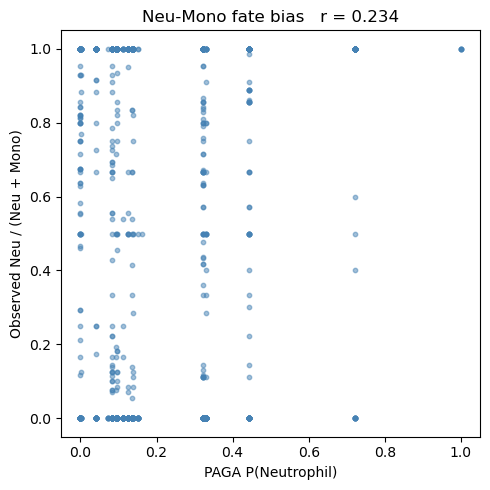

In [15]:
NEU_KEYS = ["Neutrophil", "Neu"]
MONO_KEYS = ["Monocyte", "Mono"]

if fate_df_norm is not None and corr_df is not None:
    neu_col = next((c for c in fate_df_norm.columns if c in NEU_KEYS), None)
    mono_col = next((c for c in fate_df_norm.columns if c in MONO_KEYS), None)
    if neu_col and mono_col:
        denom = fate_sub[neu_col] + fate_sub[mono_col]
        obs_bias = (fate_sub[neu_col] / denom.replace(0, np.nan)).dropna()
        best_branch = corr_df.loc[neu_col].abs().idxmax()
        pred_bias = bp_sub.loc[obs_bias.index, best_branch].values
        r, p = stats.pearsonr(pred_bias, obs_bias.values)
        print(f"Neu-Mono bias  Pearson r: {r:.4f}  (p={p:.2e})")
        print(f"(PAGA fate '{best_branch}' used as Neutrophil predictor)")
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.scatter(pred_bias, obs_bias.values, s=10, alpha=0.5, color="steelblue")
        ax.set_xlabel(f"PAGA P({best_branch})"); ax.set_ylabel("Observed Neu / (Neu + Mono)")
        ax.set_title(f"Neu-Mono fate bias   r = {r:.3f}")
        plt.tight_layout(); plt.savefig("paga_neu_mono_bias.png", dpi=80, bbox_inches="tight"); plt.show()
    else:
        print(f"Neu/Mono columns not found. Available: {list(fate_df_norm.columns)}")
else:
    print("Skipping: correlation matrix not available.")

### 10c. Wasserstein-1 distance (alphabetical lineage ordering)

Shared lineages (PAGA fates n observed): ['Baso', 'Ccr7_DC', 'Eos', 'Erythroid', 'Lymphoid', 'Meg', 'Monocyte', 'Neutrophil']

Wasserstein-1 (8 lineages, 2,034 cells): mean 2.5437  median 2.8096


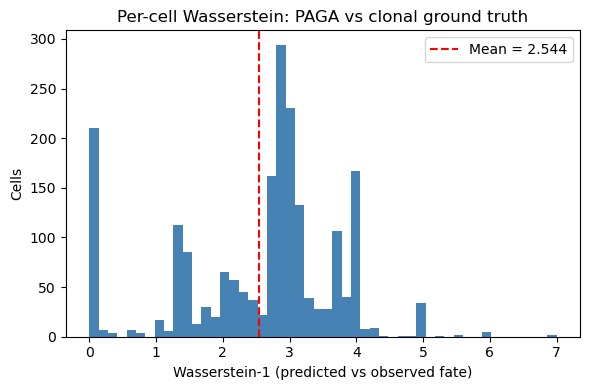

In [16]:
from scipy.stats import wasserstein_distance as _w1

if fate_df_norm is not None and fate_prob_key in adata_d2.obsm:
    bp_df_wd = pd.DataFrame(adata_d2.obsm[fate_prob_key], index=adata_d2.obs_names,
                            columns=adata_d2.uns[fate_names_key])
    shared = sorted(set(fate_df_norm.columns) & set(bp_df_wd.columns))
    print(f"Shared lineages (PAGA fates n observed): {shared}")
    common_wd = fate_df_norm.index.intersection(bp_df_wd.index)
    fate_sub_wd = fate_df_norm.loc[common_wd, shared].values.astype(float)
    bp_sub_wd = bp_df_wd.loc[common_wd, shared].values.astype(float)
    lineage_vals = np.arange(len(shared), dtype=float)
    per_cell_wd = []
    for obs_vec, pred_vec in zip(fate_sub_wd, bp_sub_wd):
        os_, ps_ = obs_vec.sum(), pred_vec.sum()
        if os_ > 0 and ps_ > 0:
            per_cell_wd.append(_w1(lineage_vals, lineage_vals, obs_vec / os_, pred_vec / ps_))
    per_cell_wd = np.array(per_cell_wd)
    print(f"\nWasserstein-1 ({len(shared)} lineages, {len(per_cell_wd):,} cells): "
          f"mean {per_cell_wd.mean():.4f}  median {np.median(per_cell_wd):.4f}")
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(per_cell_wd, bins=50, color="steelblue", edgecolor="none")
    ax.axvline(per_cell_wd.mean(), color="red", linestyle="--", label=f"Mean = {per_cell_wd.mean():.3f}")
    ax.set_xlabel("Wasserstein-1 (predicted vs observed fate)"); ax.set_ylabel("Cells")
    ax.set_title("Per-cell Wasserstein: PAGA vs clonal ground truth"); ax.legend()
    plt.tight_layout(); plt.savefig("paga_wasserstein.png", dpi=80, bbox_inches="tight"); plt.show()
else:
    print("Skipping.")

### 10d. UMAP-distance Wasserstein

UMAP-distance Wasserstein (8 lineages, 2,034 cells): mean 0.4117  median 0.4504


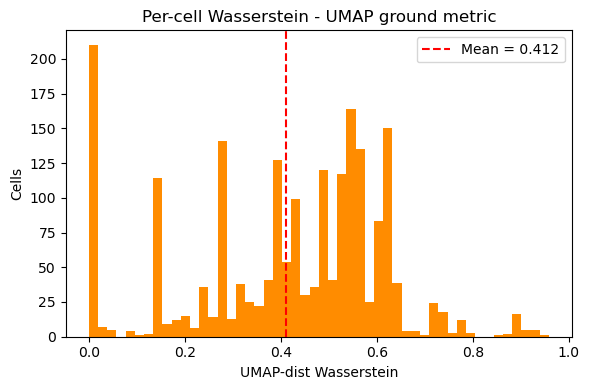

In [17]:
from scipy.optimize import linprog
from scipy.spatial.distance import cdist as _cdist

def _emd_cost_matrix(p, q, C):
    """Exact EMD between distributions p, q with cost matrix C, solved as an LP."""
    K = len(p)
    A_eq = np.zeros((2 * K, K * K)); b_eq = np.zeros(2 * K)
    for i in range(K):
        A_eq[i, i * K:(i + 1) * K] = 1.0; b_eq[i] = p[i]
    for j in range(K):
        A_eq[K + j, j::K] = 1.0; b_eq[K + j] = q[j]
    res = linprog(C.flatten(), A_eq=A_eq, b_eq=b_eq, bounds=[(0, None)] * (K * K), method="highs")
    return float(res.fun) if res.success else np.nan

if fate_df_norm is not None and fate_prob_key in adata_d2.obsm:
    bp_df_ud = pd.DataFrame(adata_d2.obsm[fate_prob_key], index=adata_d2.obs_names,
                            columns=adata_d2.uns[fate_names_key])
    shared_ud = sorted(set(fate_df_norm.columns) & set(bp_df_ud.columns))
    obs_name_arr = np.array(adata_d2.obs_names)
    terminal_umap_coords = np.array([
        adata_d2.obsm["X_umap"][np.where(obs_name_arr == bp_df_ud[b].idxmax())[0][0]] for b in shared_ud
    ])
    C_umap = _cdist(terminal_umap_coords, terminal_umap_coords)
    C_umap /= C_umap.max() if C_umap.max() > 0 else 1.0
    common_ud = fate_df_norm.index.intersection(bp_df_ud.index)
    fate_sub_ud = fate_df_norm.loc[common_ud, shared_ud].values.astype(float)
    bp_sub_ud = bp_df_ud.loc[common_ud, shared_ud].values.astype(float)
    per_cell_umap_wd = []
    for obs_vec, pred_vec in zip(fate_sub_ud, bp_sub_ud):
        os_, ps_ = obs_vec.sum(), pred_vec.sum()
        if os_ > 0 and ps_ > 0:
            per_cell_umap_wd.append(_emd_cost_matrix(obs_vec / os_, pred_vec / ps_, C_umap))
    per_cell_umap_wd = np.array(per_cell_umap_wd)
    print(f"UMAP-distance Wasserstein ({len(shared_ud)} lineages, {len(per_cell_umap_wd):,} cells): "
          f"mean {per_cell_umap_wd.mean():.4f}  median {np.median(per_cell_umap_wd):.4f}")
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(per_cell_umap_wd, bins=50, color="darkorange", edgecolor="none")
    ax.axvline(per_cell_umap_wd.mean(), color="red", linestyle="--", label=f"Mean = {per_cell_umap_wd.mean():.3f}")
    ax.set_xlabel("UMAP-dist Wasserstein"); ax.set_ylabel("Cells")
    ax.set_title("Per-cell Wasserstein - UMAP ground metric"); ax.legend()
    plt.tight_layout(); plt.savefig("paga_wasserstein_umap.png", dpi=80, bbox_inches="tight"); plt.show()
else:
    print("Skipping.")

### 10e. Pseudotime-distance Wasserstein

Terminal state pseudotime positions:
  Baso             0.2796
  Ccr7_DC          0.6403
  Eos              0.8611
  Erythroid        0.0994
  Lymphoid         0.0128
  Meg              0.1805
  Monocyte         0.2718
  Neutrophil       0.2513

Pseudotime-distance Wasserstein (8 lineages, 2,034 cells): mean 0.1733  median 0.1707


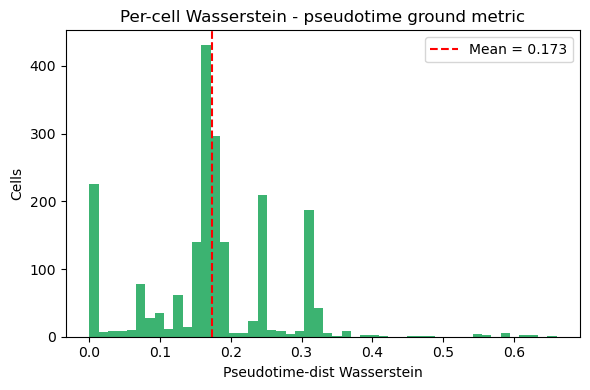

In [18]:
from scipy.stats import wasserstein_distance as _w1_pt

if fate_df_norm is not None and fate_prob_key in adata_d2.obsm and pseudo_key in adata_d2.obs:
    bp_df_pt = pd.DataFrame(adata_d2.obsm[fate_prob_key], index=adata_d2.obs_names,
                            columns=adata_d2.uns[fate_names_key])
    shared_pt = sorted(set(fate_df_norm.columns) & set(bp_df_pt.columns))
    obs_name_arr_pt = np.array(adata_d2.obs_names)
    pt_positions = np.array([
        float(adata_d2.obs[pseudo_key].iloc[np.where(obs_name_arr_pt == bp_df_pt[b].idxmax())[0][0]])
        for b in shared_pt
    ])
    print("Terminal state pseudotime positions:")
    for b, ptv in zip(shared_pt, pt_positions):
        print(f"  {b:15s}  {ptv:.4f}")
    common_pt = fate_df_norm.index.intersection(bp_df_pt.index)
    fate_sub_pt = fate_df_norm.loc[common_pt, shared_pt].values.astype(float)
    bp_sub_pt = bp_df_pt.loc[common_pt, shared_pt].values.astype(float)
    per_cell_pt_wd = []
    for obs_vec, pred_vec in zip(fate_sub_pt, bp_sub_pt):
        os_, ps_ = obs_vec.sum(), pred_vec.sum()
        if os_ > 0 and ps_ > 0:
            per_cell_pt_wd.append(_w1_pt(pt_positions, pt_positions, obs_vec / os_, pred_vec / ps_))
    per_cell_pt_wd = np.array(per_cell_pt_wd)
    print(f"\nPseudotime-distance Wasserstein ({len(shared_pt)} lineages, {len(per_cell_pt_wd):,} cells): "
          f"mean {per_cell_pt_wd.mean():.4f}  median {np.median(per_cell_pt_wd):.4f}")
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(per_cell_pt_wd, bins=50, color="mediumseagreen", edgecolor="none")
    ax.axvline(per_cell_pt_wd.mean(), color="red", linestyle="--", label=f"Mean = {per_cell_pt_wd.mean():.3f}")
    ax.set_xlabel("Pseudotime-dist Wasserstein"); ax.set_ylabel("Cells")
    ax.set_title("Per-cell Wasserstein - pseudotime ground metric"); ax.legend()
    plt.tight_layout(); plt.savefig("paga_wasserstein_pseudotime.png", dpi=80, bbox_inches="tight"); plt.show()
else:
    print("Skipping.")

### 10f. Cross-entropy of predicted vs observed clone fate distributions

For each cloned day-2 cell, over lineages shared by PAGA fates and observed clonal labels,
renormalize both to distributions and compute `CE = -sum_k obs_k * log(pred_k)`. The predicted
distribution is **Laplace-smoothed toward uniform (alpha=0.01)** so that PAGA's hard-zero
cluster-level predictions don't blow up the mean — this is applied identically to any model so
PAGA and Palantir stay comparable. Lower is better; a uniform baseline is shown for context.

Cross-entropy over 8 shared lineages ['Baso', 'Ccr7_DC', 'Eos', 'Erythroid', 'Lymphoid', 'Meg', 'Monocyte', 'Neutrophil'], 2,034 cells
  PAGA      mean 2.5577  median 2.0183
  Uniform   mean 2.0794  (baseline)


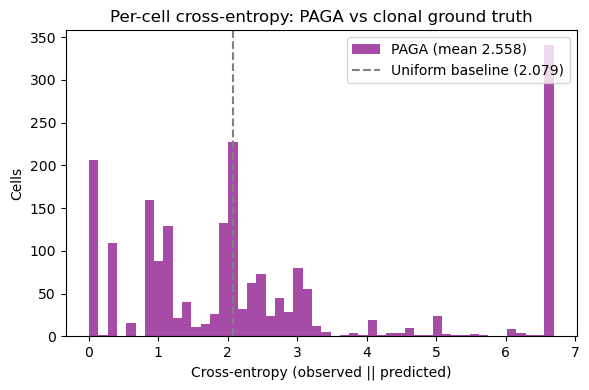

In [19]:
def cross_entropy(obs, pred, eps=1e-12, alpha=0.01):
    """CE(obs || pred) over a shared lineage set. The predicted distribution is
    Laplace-smoothed toward uniform (alpha) so hard-zero predictions don't blow up
    the metric -- applied identically to any model, keeping PAGA/Palantir comparable."""
    obs = np.asarray(obs, float); pred = np.asarray(pred, float)
    obs = obs / obs.sum(); pred = pred / pred.sum()
    K = len(pred)
    pred = (1.0 - alpha) * pred + alpha * (np.ones(K) / K)
    return float(-np.sum(obs * np.log(pred + eps)))

paga_ce_mean = np.nan
if fate_df_norm is not None and fate_prob_key in adata_d2.obsm:
    bp_df_ce = pd.DataFrame(adata_d2.obsm[fate_prob_key], index=adata_d2.obs_names,
                            columns=adata_d2.uns[fate_names_key])
    shared_ce = sorted(set(fate_df_norm.columns) & set(bp_df_ce.columns))
    common_ce = fate_df_norm.index.intersection(bp_df_ce.index)
    obs_m = fate_df_norm.loc[common_ce, shared_ce].values.astype(float)
    pred_m = bp_df_ce.loc[common_ce, shared_ce].values.astype(float)
    K = len(shared_ce); unif = np.ones(K) / K
    ce_vals, ce_unif = [], []
    for o, p in zip(obs_m, pred_m):
        if o.sum() > 0 and p.sum() > 0:
            ce_vals.append(cross_entropy(o, p)); ce_unif.append(cross_entropy(o, unif))
    ce_vals = np.array(ce_vals); ce_unif = np.array(ce_unif)
    paga_ce_mean = ce_vals.mean()
    print(f"Cross-entropy over {K} shared lineages {shared_ce}, {len(ce_vals):,} cells")
    print(f"  PAGA      mean {ce_vals.mean():.4f}  median {np.median(ce_vals):.4f}")
    print(f"  Uniform   mean {ce_unif.mean():.4f}  (baseline)")
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(ce_vals, bins=50, color="purple", alpha=0.7, label=f"PAGA (mean {ce_vals.mean():.3f})")
    ax.axvline(ce_unif.mean(), color="gray", linestyle="--", label=f"Uniform baseline ({ce_unif.mean():.3f})")
    ax.set_xlabel("Cross-entropy (observed || predicted)"); ax.set_ylabel("Cells")
    ax.set_title("Per-cell cross-entropy: PAGA vs clonal ground truth"); ax.legend()
    plt.tight_layout(); plt.savefig("paga_cross_entropy.png", dpi=80, bbox_inches="tight"); plt.show()
else:
    print("Skipping cross-entropy.")

## 11. Save

In [20]:
print(f"Saving to {OUTPUT_H5AD} ...")
adata_d2.write_h5ad(OUTPUT_H5AD)
result_cols = [c for c in adata_d2.obs.columns
               if "paga" in c or c in [time_col, clone_col, celltype_col, pseudo_key, "leiden"]]
adata_d2.obs[result_cols].to_csv("paga_day2_results.csv")
print("CSV saved to paga_day2_results.csv")

print("=" * 55)
print("PAGA ANALYSIS COMPLETE")
print("=" * 55)
print(f"  Day-2 cells:    {adata_d2.n_obs:,}")
print(f"  Leiden clusters:{adata_d2.obs['leiden'].nunique()}")
print(f"  Terminal fates: {adata_d2.uns[fate_names_key]}")
print(f"  Output h5ad:    {OUTPUT_H5AD}")

Saving to larry_day2_paga.h5ad ...


CSV saved to paga_day2_results.csv
PAGA ANALYSIS COMPLETE
  Day-2 cells:    28,249
  Leiden clusters:24
  Terminal fates: ['Baso', 'Ccr7_DC', 'Eos', 'Erythroid', 'Lymphoid', 'Meg', 'Monocyte', 'Neutrophil']
  Output h5ad:    larry_day2_paga.h5ad


## 12. PAGA vs Palantir comparison (shared metrics)

Best-effort side-by-side. Computes the three shared metrics for PAGA and, if
`larry_day2_palantir.h5ad` is present, for Palantir too, on their common cloned day-2 cells
and shared lineage set. Run the Palantir notebook's Save cell first to produce that file.

In [21]:
def shared_metrics(adata, prob_key, names_key):
    fcols = sorted(c for c in adata.obs.columns if c.startswith("fate_frac_"))
    hf = adata.obs[fcols[0]].notna()
    fd = adata.obs.loc[hf, fcols].copy()
    fd = fd.loc[:, fd.sum() > 0]
    fd.columns = [c.replace("fate_frac_", "") for c in fd.columns]
    names = list(adata.uns[names_key])
    bp = pd.DataFrame(adata.obsm[prob_key], index=adata.obs_names, columns=names)
    common = fd.index.intersection(bp.index)
    fd, bp = fd.loc[common], bp.loc[common]
    shared = sorted(set(fd.columns) & set(bp.columns))
    # mean diagonal Pearson r over shared fates
    rs = []
    for f in shared:
        x, y = fd[f].values, bp[f].values
        if x.std() > 0 and y.std() > 0:
            rs.append(stats.pearsonr(x, y)[0])
    mean_r = float(np.nanmean(rs)) if rs else np.nan
    # Neu-Mono bias r
    nm = np.nan
    if "Neutrophil" in fd.columns and "Monocyte" in fd.columns and "Neutrophil" in bp.columns:
        denom = (fd["Neutrophil"] + fd["Monocyte"]).replace(0, np.nan)
        ob = (fd["Neutrophil"] / denom).dropna()
        nm = stats.pearsonr(bp.loc[ob.index, "Neutrophil"].values, ob.values)[0]
    # cross-entropy
    om = fd[shared].values.astype(float); pm = bp[shared].values.astype(float)
    ce = [cross_entropy(o, p) for o, p in zip(om, pm) if o.sum() > 0 and p.sum() > 0]
    return {"mean_diag_pearson_r": mean_r, "neu_mono_bias_r": nm,
            "cross_entropy_mean": float(np.mean(ce)) if ce else np.nan,
            "n_shared_lineages": len(shared), "shared": shared}

import os
rows = {"PAGA": shared_metrics(adata_d2, fate_prob_key, fate_names_key)}
if os.path.exists(PALANTIR_H5AD):
    ad_p = anndata.read_h5ad(PALANTIR_H5AD)
    if "palantir_fate_probabilities" in ad_p.obsm and "palantir_branch_names" in ad_p.uns:
        rows["Palantir"] = shared_metrics(ad_p, "palantir_fate_probabilities", "palantir_branch_names")
    else:
        print("Palantir h5ad present but missing fate-prob obsm/uns; skipping Palantir column.")
else:
    print(f"{PALANTIR_H5AD} not found - showing PAGA only. "
          "Run 02_palantir.ipynb's Save cell to enable the side-by-side.")

cmp = pd.DataFrame(rows).T[["mean_diag_pearson_r", "neu_mono_bias_r", "cross_entropy_mean", "n_shared_lineages"]]
print("\n=== Shared-metric comparison (higher r better; lower CE better) ===")
print(cmp.round(4).to_string())

larry_day2_palantir.h5ad not found - showing PAGA only. Run 02_palantir.ipynb's Save cell to enable the side-by-side.

=== Shared-metric comparison (higher r better; lower CE better) ===
     mean_diag_pearson_r neu_mono_bias_r cross_entropy_mean n_shared_lineages
PAGA            0.260956         0.23372           2.557687                 8
